# Eigenvalues, Eigenvectors, and Principal Component Analysis

This notebook explores eigenvalues, eigenvectors, and their application to Principal Component Analysis (PCA). We'll implement these concepts from scratch and visualize their geometric interpretations.

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

from phase0.linear_algebra.eigen import power_iteration, eigendecomposition
from phase0.linear_algebra.pca import pca_from_scratch, explained_variance_ratio, cumulative_explained_variance_ratio
from phase0.linear_algebra.matrix_viz import plot_linear_transformation

# Set random seed for reproducibility
np.random.seed(42)

## 1. Understanding Eigenvalues and Eigenvectors

Eigenvalues and eigenvectors are fundamental concepts in linear algebra. An eigenvector of a linear transformation is a non-zero vector that changes only by a scalar factor when that linear transformation is applied to it. The corresponding eigenvalue is the factor by which the eigenvector is scaled.

Mathematically, if $A$ is a square matrix, $v$ is an eigenvector, and $\lambda$ is the corresponding eigenvalue, then:

$$Av = \lambda v$$

Let's explore this concept with some examples.

In [46]:
# Create a simple 2x2 matrix
A = np.array([[3, 1], 
              [1, 3]])

print("Matrix A:")
print(A)

Matrix A:
[[3 1]
 [1 3]]


### 1.1 Computing Eigenvalues and Eigenvectors

Let's compute the eigenvalues and eigenvectors of this matrix using our custom implementation.

In [47]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = eigendecomposition(A)

print("Eigenvalues:")
print(eigenvalues)
print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[2. 4.]

Eigenvectors:
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


### 1.2 Verifying the Eigenvalue Equation

Let's verify that $Av = \lambda v$ for each eigenvector.

In [48]:
for i in range(len(eigenvalues)):
    eigenvalue = eigenvalues[i]
    eigenvector = eigenvectors[:, i]
    
    # Compute Av
    Av = A @ eigenvector
    
    # Compute λv
    lambda_v = eigenvalue * eigenvector
    
    print(f"Eigenvalue {i+1}: {eigenvalue:.4f}")
    print(f"Eigenvector {i+1}: {eigenvector}")
    print(f"A·v: {Av}")
    print(f"λ·v: {lambda_v}")
    print(f"Are they equal? {np.allclose(Av, lambda_v)}\n")

Eigenvalue 1: 2.0000
Eigenvector 1: [-0.70710678  0.70710678]
A·v: [-1.41421356  1.41421356]
λ·v: [-1.41421356  1.41421356]
Are they equal? True

Eigenvalue 2: 4.0000
Eigenvector 2: [0.70710678 0.70710678]
A·v: [2.82842712 2.82842712]
λ·v: [2.82842712 2.82842712]
Are they equal? True



### 1.3 Visualizing Eigenvectors

Eigenvectors have a special geometric interpretation: they represent directions that are only scaled (not rotated) by the linear transformation. Let's visualize this.

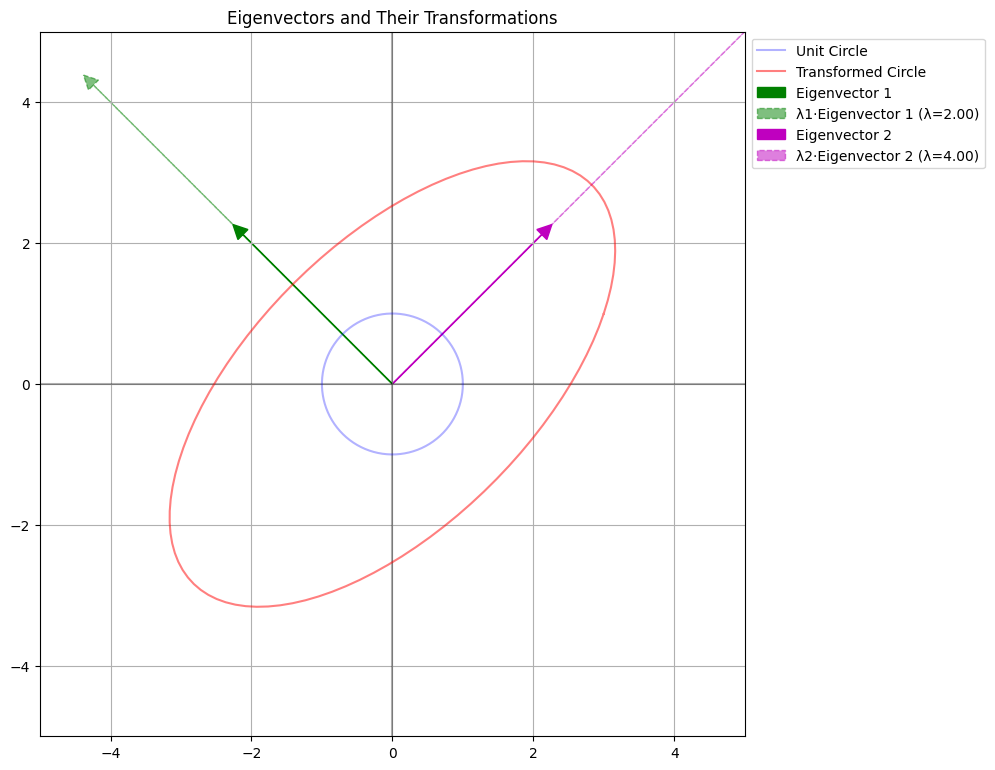

In [49]:
def plot_eigenvectors(A, eigenvalues, eigenvectors):
    """Plot the effect of a matrix on its eigenvectors."""
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Set up the axis
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.grid(True)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    ax.set_aspect('equal')
    
    # Plot unit circle
    theta = np.linspace(0, 2*np.pi, 100)
    x = np.cos(theta)
    y = np.sin(theta)
    ax.plot(x, y, 'b-', alpha=0.3, label='Unit Circle')
    
    # Plot transformed unit circle
    circle_points = np.vstack((x, y))
    transformed_points = A @ circle_points
    ax.plot(transformed_points[0, :], transformed_points[1, :], 'r-', alpha=0.5, label='Transformed Circle')
    
    # Plot eigenvectors and their transformations
    colors = ['g', 'm', 'c', 'y']
    for i in range(len(eigenvalues)):
        eigenvalue = eigenvalues[i]
        eigenvector = eigenvectors[:, i]
        
        # Scale eigenvector for visualization
        scaled_eigenvector = 3 * eigenvector / np.linalg.norm(eigenvector)
        
        # Plot original eigenvector
        ax.arrow(0, 0, scaled_eigenvector[0], scaled_eigenvector[1], 
                 head_width=0.2, head_length=0.2, fc=colors[i], ec=colors[i],
                 label=f'Eigenvector {i+1}')
        
        # Plot transformed eigenvector
        transformed_eigenvector = A @ scaled_eigenvector
        ax.arrow(0, 0, transformed_eigenvector[0], transformed_eigenvector[1], 
                 head_width=0.2, head_length=0.2, fc=colors[i], ec=colors[i], alpha=0.5,
                 linestyle='dashed', label=f'λ{i+1}·Eigenvector {i+1} (λ={eigenvalue:.2f})')
    
    ax.set_title('Eigenvectors and Their Transformations')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

# Plot eigenvectors
plot_eigenvectors(A, eigenvalues, eigenvectors)

## 2. Principal Component Analysis (PCA)

Principal Component Analysis is a dimensionality reduction technique that uses eigenvalues and eigenvectors of the covariance matrix to identify the most important features in a dataset.

Let's implement PCA from scratch and apply it to a simple dataset.

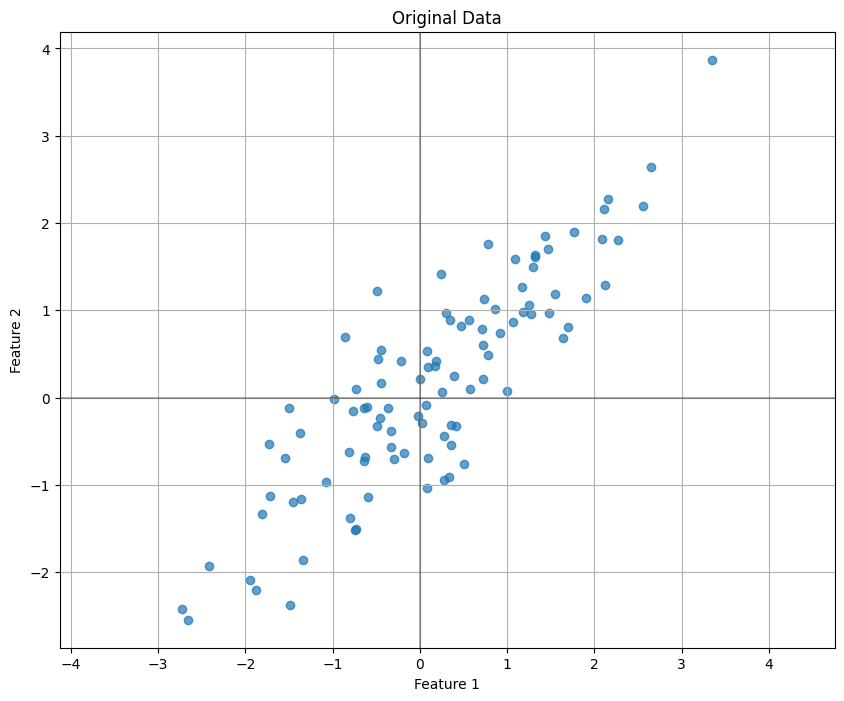

In [50]:
# Generate a synthetic dataset with correlated features
n_samples = 100

# Create a covariance matrix
cov_matrix = np.array([[2.0, 1.8], 
                        [1.8, 2.0]])

# Generate random data with this covariance
mean = [0, 0]
X = np.random.multivariate_normal(mean, cov_matrix, n_samples)

# Plot the data
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True)
plt.title('Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.axis('equal')
plt.show()

### 2.1 Implementing PCA from Scratch

Now let's implement PCA from scratch and apply it to our dataset.

In [51]:
# Perform PCA
components, explained_variance, transformed_data = pca_from_scratch(X)

print("Principal Components:")
print(components)
print("\nExplained Variance:")
print(explained_variance)
print("\nExplained Variance Ratio:")
print(explained_variance_ratio(explained_variance))
print("\nCumulative Explained Variance Ratio:")
print(cumulative_explained_variance_ratio(explained_variance))

Principal Components:
[[-0.71366318  0.70048902]
 [-0.70048902 -0.71366318]]

Explained Variance:
[2.78665932 0.19931916]

Explained Variance Ratio:
[0.93324829 0.06675171]

Cumulative Explained Variance Ratio:
[0.93324829 1.        ]


### 2.2 Visualizing PCA Results

Let's visualize the principal components and the transformed data.

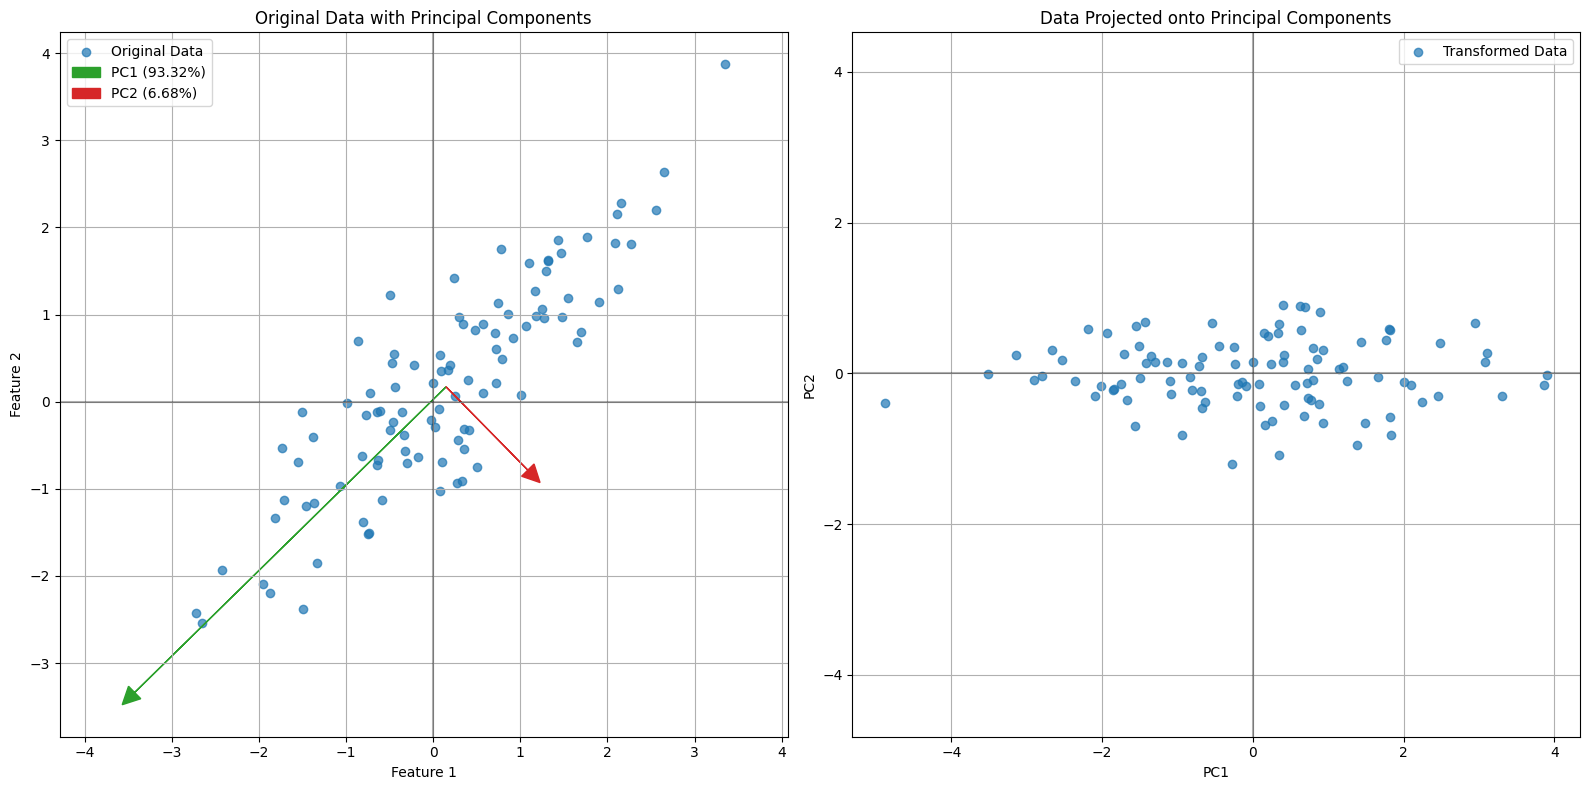

In [52]:
def plot_pca_results(X, components, transformed_data):
    """Plot PCA results including original data, principal components, and transformed data."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot original data with principal components
    ax1.scatter(X[:, 0], X[:, 1], alpha=0.7, label='Original Data')
    
    # Plot principal components
    mean = np.mean(X, axis=0)
    for i, component in enumerate(components.T):
        # Scale component for visualization
        component_scaled = component * 3 * np.sqrt(explained_variance[i])
        ax1.arrow(mean[0], mean[1], component_scaled[0], component_scaled[1], 
                 head_width=0.2, head_length=0.2, fc=f'C{i+2}', ec=f'C{i+2}',
                 label=f'PC{i+1} ({explained_variance_ratio(explained_variance)[i]:.2%})')
    
    ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    ax1.grid(True)
    ax1.set_title('Original Data with Principal Components')
    ax1.set_xlabel('Feature 1')
    ax1.set_ylabel('Feature 2')
    ax1.axis('equal')
    ax1.legend()
    
    # Plot transformed data
    ax2.scatter(transformed_data[:, 0], transformed_data[:, 1], alpha=0.7, label='Transformed Data')
    ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax2.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    ax2.grid(True)
    ax2.set_title('Data Projected onto Principal Components')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.axis('equal')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Plot PCA results
plot_pca_results(X, components, transformed_data)

## 3. Dimensionality Reduction with PCA

Now let's apply PCA to reduce the dimensionality of a dataset and see how well we can reconstruct the original data.

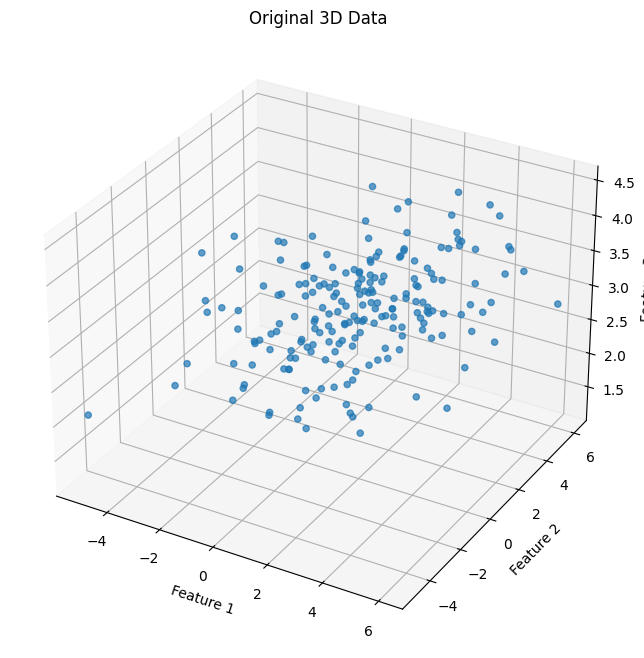

In [53]:
# Let's create a more complex dataset with 3 dimensions
n_samples = 200
cov_matrix = np.array([
    [3.0, 2.8, 0.2],
    [2.8, 3.0, 0.3],
    [0.2, 0.3, 0.5]
])
mean = [1, 2, 3]
X_3d = np.random.multivariate_normal(mean, cov_matrix, n_samples)

# Plot the 3D data
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], alpha=0.7)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.set_title('Original 3D Data')
plt.show()

In [54]:
# Perform PCA on the 3D data
components_3d, explained_variance_3d, transformed_data_3d = pca_from_scratch(X_3d)

print("Explained Variance:")
print(explained_variance_3d)
print("\nExplained Variance Ratio:")
variance_ratio = explained_variance_ratio(explained_variance_3d)
print(variance_ratio)
print("\nCumulative Explained Variance Ratio:")
cumulative_ratio = cumulative_explained_variance_ratio(explained_variance_3d)
print(cumulative_ratio)

Explained Variance:
[6.2267488  0.43725447 0.18729736]

Explained Variance Ratio:
[0.90884186 0.06382065 0.02733749]

Cumulative Explained Variance Ratio:
[0.90884186 0.97266251 1.        ]


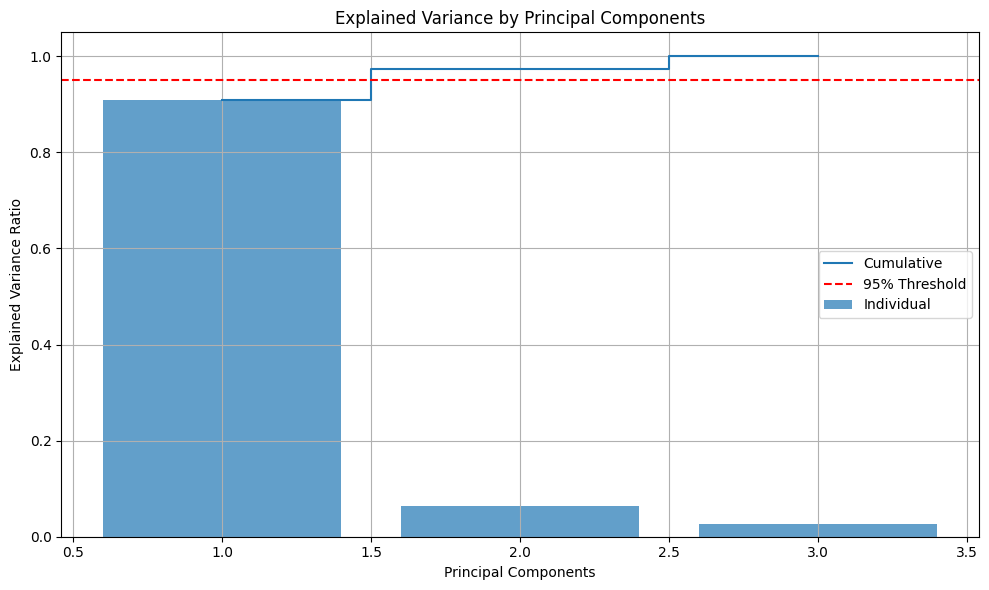

In [55]:
# Visualize the explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(variance_ratio) + 1), variance_ratio, alpha=0.7, label='Individual')
plt.step(range(1, len(cumulative_ratio) + 1), cumulative_ratio, where='mid', label='Cumulative')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 3.1 Reducing Dimensions and Reconstructing Data

Let's reduce the dimensionality to 2 components and then reconstruct the data.

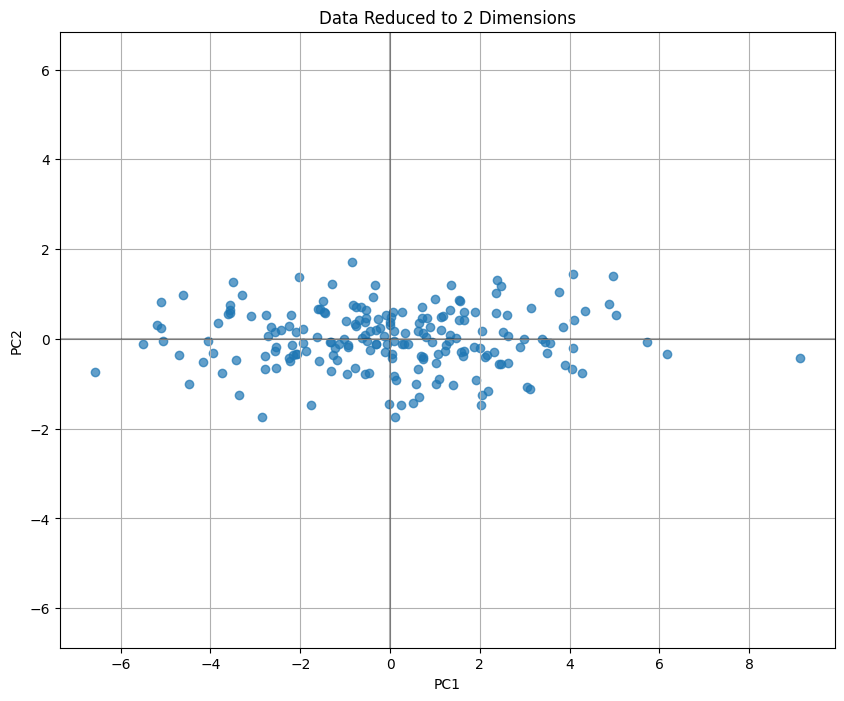

In [56]:
# Reduce to 2 dimensions
components_reduced, _, transformed_data_reduced = pca_from_scratch(X_3d, n_components=2)

# Plot the reduced data
plt.figure(figsize=(10, 8))
plt.scatter(transformed_data_reduced[:, 0], transformed_data_reduced[:, 1], alpha=0.7)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True)
plt.title('Data Reduced to 2 Dimensions')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.axis('equal')
plt.show()

Mean Squared Reconstruction Error: 0.1864


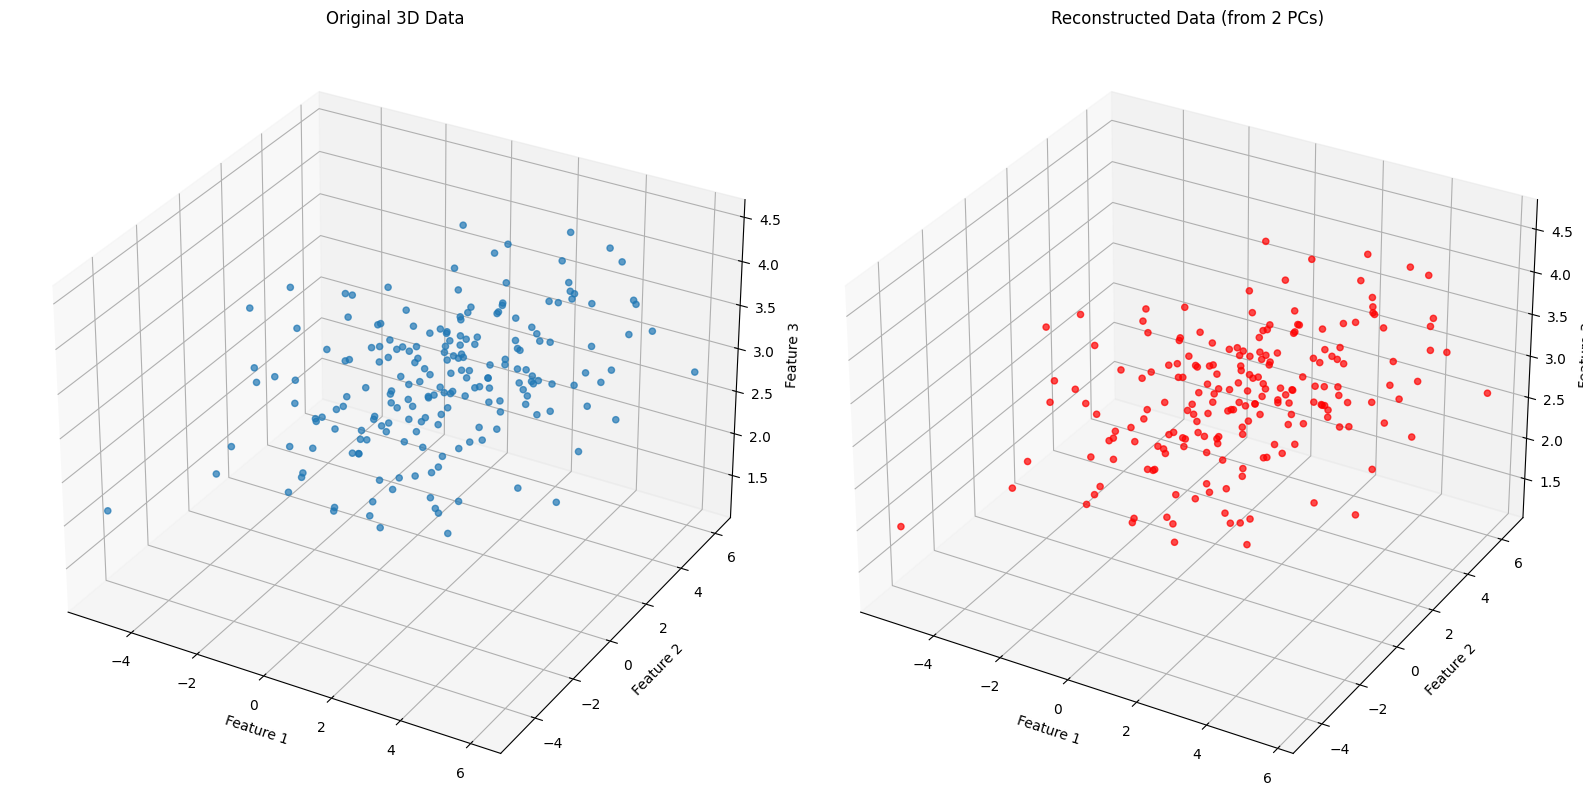

In [57]:
# Reconstruct the data
original_mean = np.mean(X_3d, axis=0)
reconstructed_data = transformed_data_reduced @ components_reduced.T + original_mean

# Calculate reconstruction error
reconstruction_error = np.mean(np.sum((X_3d - reconstructed_data) ** 2, axis=1))
print(f"Mean Squared Reconstruction Error: {reconstruction_error:.4f}")

# Plot original vs reconstructed data
fig = plt.figure(figsize=(16, 8))

# Original data
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], alpha=0.7)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')
ax1.set_title('Original 3D Data')

# Reconstructed data
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(reconstructed_data[:, 0], reconstructed_data[:, 1], reconstructed_data[:, 2], alpha=0.7, color='r')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_zlabel('Feature 3')
ax2.set_title('Reconstructed Data (from 2 PCs)')

plt.tight_layout()
plt.show()

## 4. Application: Image Compression with PCA

Let's apply PCA to compress a simple grayscale image.

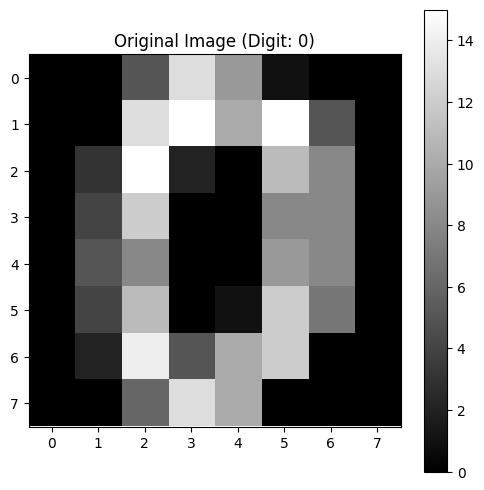

In [58]:
# Create a simple grayscale image
from sklearn.datasets import load_digits

# Load digits dataset
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# Select one image
image = digits.images[0]

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title(f'Original Image (Digit: {y_digits[0]})')
plt.colorbar()
plt.grid(False)
plt.show()

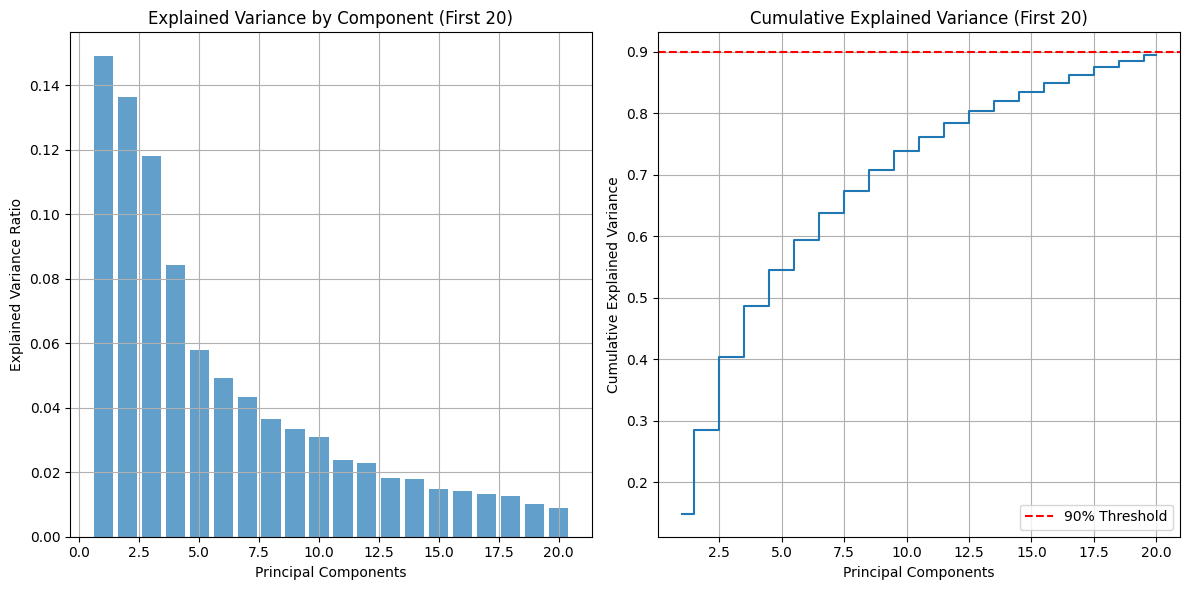

In [59]:
# Apply PCA to the entire dataset
components_digits, explained_variance_digits, _ = pca_from_scratch(X_digits)

# Plot explained variance
variance_ratio_digits = explained_variance_ratio(explained_variance_digits)
cumulative_ratio_digits = cumulative_explained_variance_ratio(explained_variance_digits)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(range(1, 21), variance_ratio_digits[:20], alpha=0.7)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Component (First 20)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.step(range(1, 21), cumulative_ratio_digits[:20], where='mid')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.xlabel('Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance (First 20)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

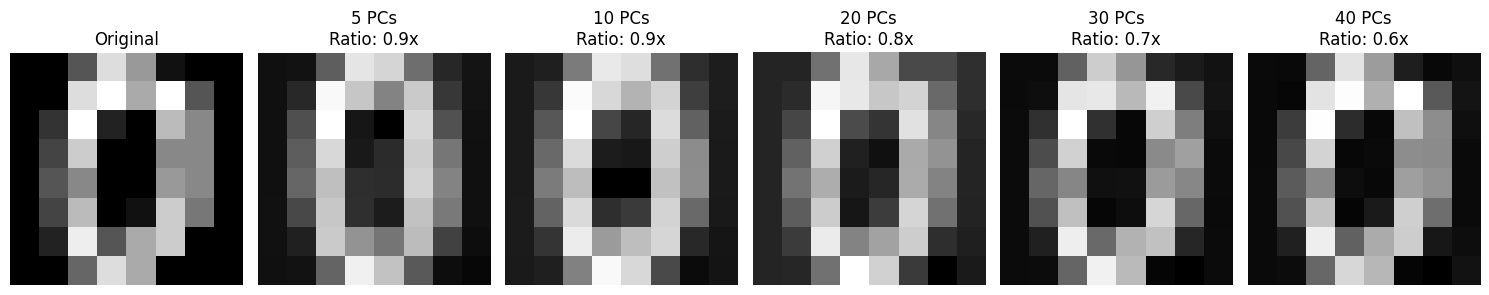

In [60]:
# Function to compress and reconstruct an image using PCA
def compress_image_with_pca(image, n_components):
    """Compress an image using PCA and reconstruct it."""
    # Flatten the image
    flattened = image.flatten().reshape(1, -1)
    
    # Apply PCA to the entire dataset to get components
    components, _, _ = pca_from_scratch(X_digits, n_components=n_components)
    
    # Project the image onto the principal components
    mean = np.mean(X_digits, axis=0)
    centered = flattened - mean
    projected = centered @ components
    
    # Reconstruct the image
    reconstructed_flat = projected @ components.T + mean
    reconstructed = reconstructed_flat.reshape(image.shape)
    
    # Calculate compression ratio
    original_size = image.size
    compressed_size = n_components * (1 + image.size / n_components)
    compression_ratio = original_size / compressed_size
    
    return reconstructed, compression_ratio

# Compress the image with different numbers of components
n_components_list = [5, 10, 20, 30, 40]
fig, axes = plt.subplots(1, len(n_components_list) + 1, figsize=(15, 4))

# Original image
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Compressed images
for i, n_comp in enumerate(n_components_list):
    reconstructed, ratio = compress_image_with_pca(image, n_comp)
    axes[i+1].imshow(reconstructed, cmap='gray')
    axes[i+1].set_title(f'{n_comp} PCs\nRatio: {ratio:.1f}x')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

## 5. Conclusion

In this notebook, we've explored eigenvalues, eigenvectors, and their application to Principal Component Analysis. We've implemented these concepts from scratch and visualized their geometric interpretations.

Key takeaways:
- Eigenvectors represent directions that are only scaled (not rotated) by a linear transformation
- PCA uses the eigenvectors of the covariance matrix to identify the most important features in a dataset
- PCA can be used for dimensionality reduction, data visualization, and compression
- The quality of reconstruction depends on the amount of variance explained by the selected principal components

Next steps could include:
- Applying PCA to real-world datasets
- Exploring other dimensionality reduction techniques like t-SNE or UMAP
- Implementing more advanced eigenvalue algorithms for larger matrices